In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/heart.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.shape

(918, 12)

In [6]:
for col in df.select_dtypes(include=['object']).columns:
    print(f'number of column {col} is : ',df[col].nunique())
    print(f'number of column {col} is : ',df[col].unique())

number of column Sex is :  2
number of column Sex is :  ['M' 'F']
number of column ChestPainType is :  4
number of column ChestPainType is :  ['ATA' 'NAP' 'ASY' 'TA']
number of column RestingECG is :  3
number of column RestingECG is :  ['Normal' 'ST' 'LVH']
number of column ExerciseAngina is :  2
number of column ExerciseAngina is :  ['N' 'Y']
number of column ST_Slope is :  3
number of column ST_Slope is :  ['Up' 'Flat' 'Down']


In [7]:
df['Sex'] = df['Sex'].map({'M':1, 'F':0})

df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y':1, 'N':0})

In [8]:
df = pd.get_dummies(
    df,
    columns=['ChestPainType', 'RestingECG', 'ST_Slope'],
    drop_first=True
)

In [9]:
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,0,160,180,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,1,130,283,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,0,138,214,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,1,150,195,0,122,0,0.0,0,False,True,False,True,False,False,True


In [10]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

outlier_count = {}

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_count[col] = outliers.shape[0]

print(outlier_count)

{'Age': 0, 'RestingBP': 28, 'Cholesterol': 183, 'MaxHR': 2, 'Oldpeak': 16}


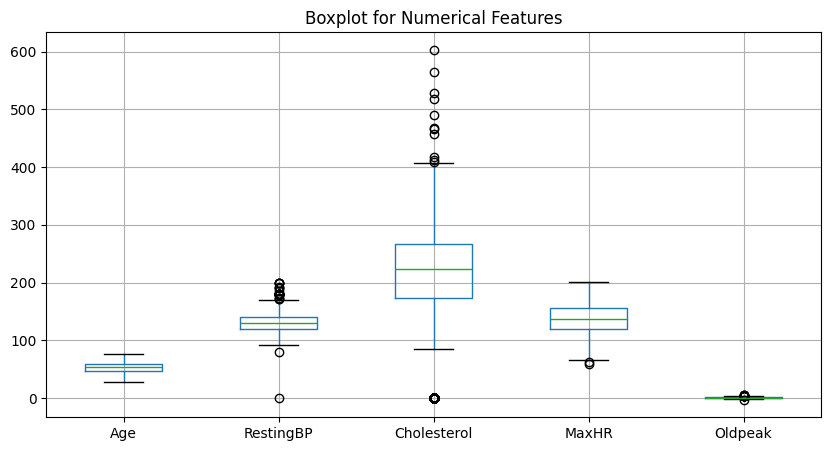

In [11]:
df[numerical_cols].boxplot(figsize=(10,5))

plt.title("Boxplot for Numerical Features")

plt.show()

In [12]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

/tmp/ipykernel_14455/2759051815.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="HeartDisease", data=df, palette="Set2")


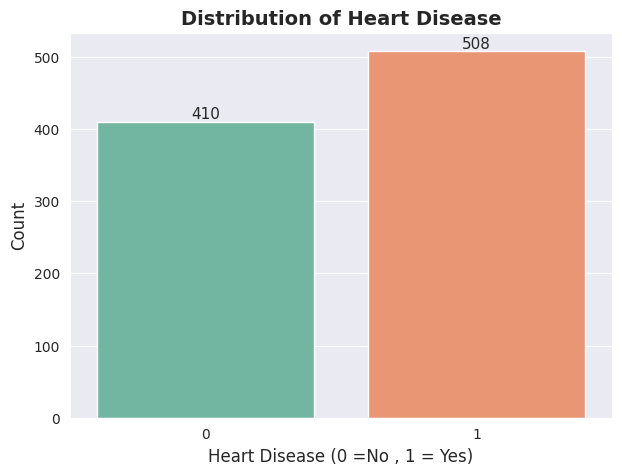

In [69]:
sns.set_style("darkgrid")
plt.figure(figsize=(7,5))

ax = sns.countplot(x="HeartDisease", data=df, palette="Set2")

plt.title("Distribution of Heart Disease", fontsize=14, fontweight="bold")


plt.xlabel("Heart Disease (0 =No , 1 = Yes)", fontsize=12)
plt.ylabel("Count", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.show()

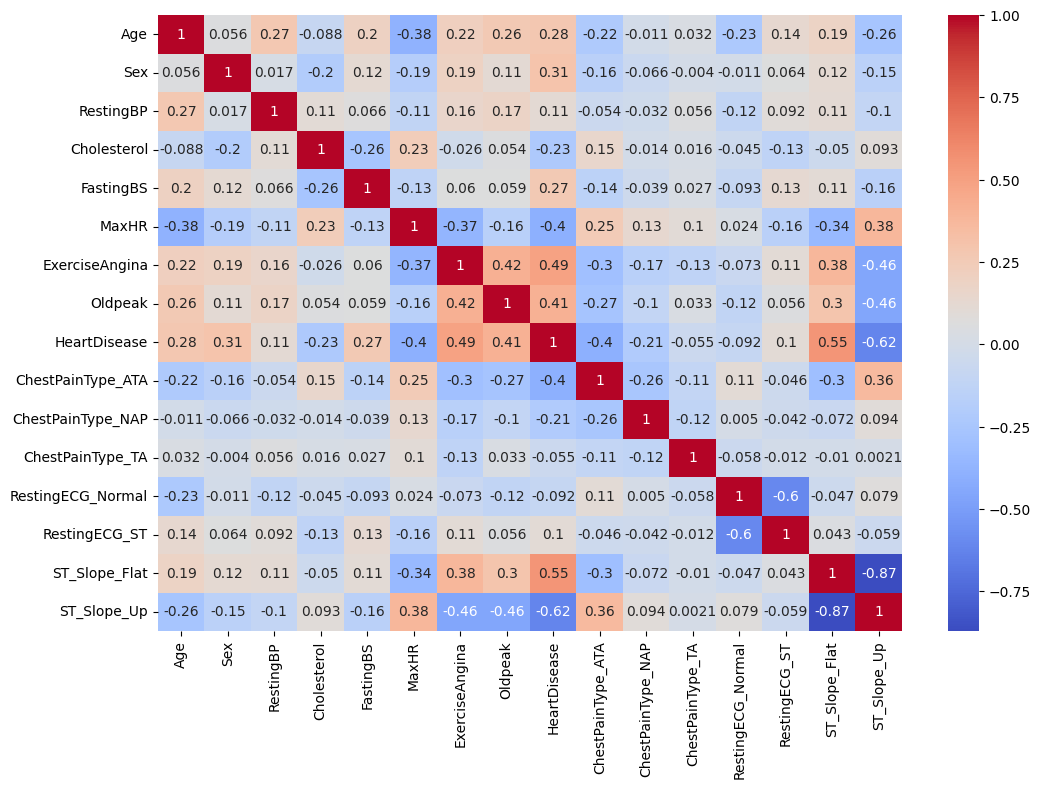

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.show()

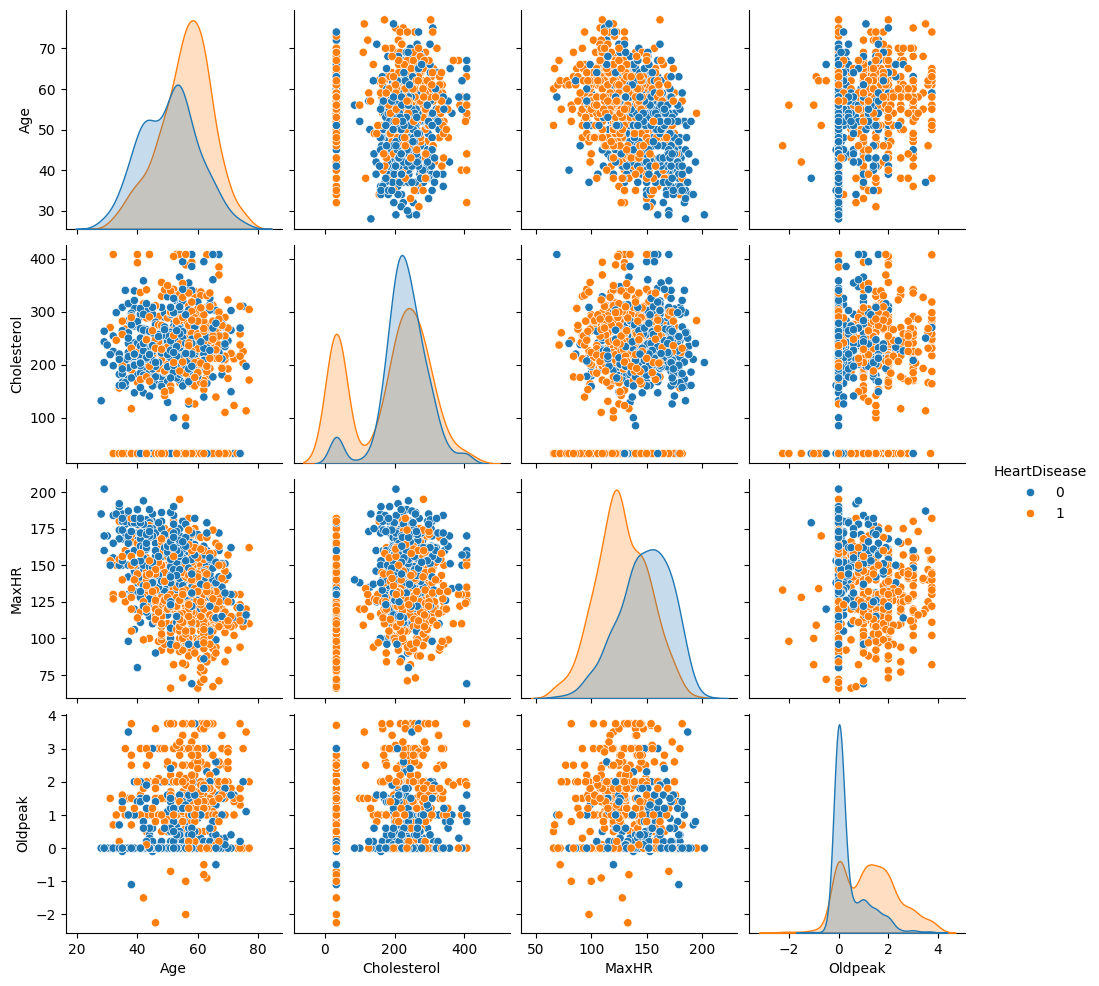

In [18]:
sns.pairplot(df[['Age','Cholesterol','MaxHR','Oldpeak','HeartDisease']],
             hue='HeartDisease')

plt.show()

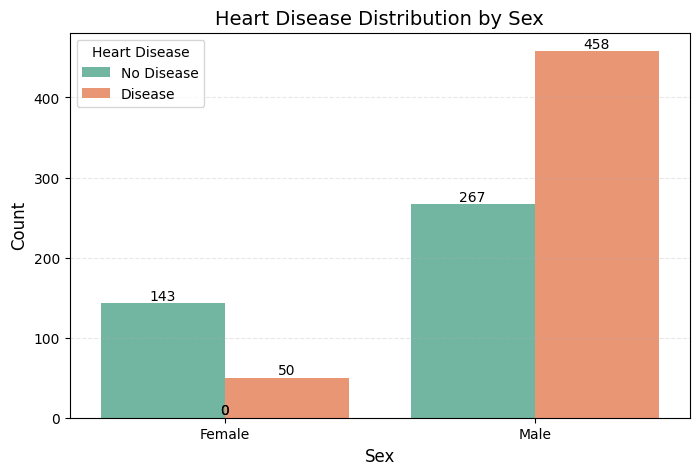

In [65]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Sex',
    hue='HeartDisease',
    data=df,
    palette='Set2'
)
plt.xticks([0,1], ['Female', 'Male'])
plt.title('Heart Disease Distribution by Sex', fontsize=14)
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Heart Disease', labels=['No Disease', 'Disease'])
ax = plt.gca()
for p in ax.patches:

    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

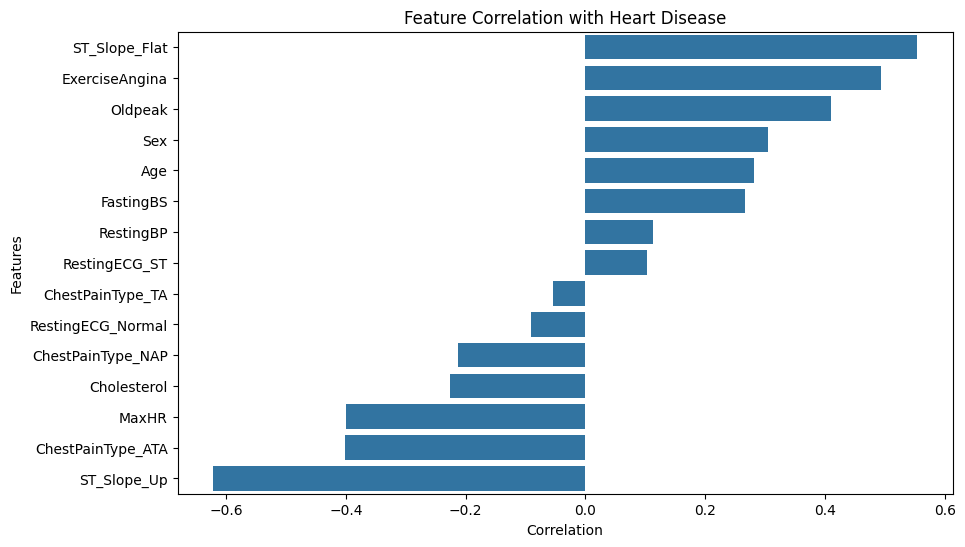

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns


corr_target = df.corr()['HeartDisease'].sort_values(ascending=False)


corr_target = corr_target.drop('HeartDisease')


corr_df = corr_target.reset_index()

corr_df.columns = ['Feature', 'Correlation']


plt.figure(figsize=(10,6))

sns.barplot(
    x='Correlation',
    y='Feature',
    data=corr_df
)

plt.title('Feature Correlation with Heart Disease')

plt.xlabel('Correlation')

plt.ylabel('Features')

plt.show()

In [23]:
X=df.drop(['HeartDisease'],axis=1)

In [24]:
y=df['HeartDisease']

In [25]:
X.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289.0,0,172,0,0.0,True,False,False,True,False,False,True
1,49,0,160,180.0,0,156,0,1.0,False,True,False,True,False,True,False
2,37,1,130,283.0,0,98,0,0.0,True,False,False,False,True,False,True
3,48,0,138,214.0,0,108,1,1.5,False,False,False,True,False,True,False
4,54,1,150,195.0,0,122,0,0.0,False,True,False,True,False,False,True


In [26]:
y.head()

,HeartDisease
0,0
1,1
2,0
3,1
4,0


In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                   test_size= 0.20, random_state=100, stratify=y)

print("X_train = ",X_train.shape ," y_train = ", y_train.shape)
print("X_test  = ",X_test.shape ," y_test  = ", y_test.shape)

X_train =  (734, 15)  y_train =  (734,)
X_test  =  (184, 15)  y_test  =  (184,)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,\
    f1_score ,confusion_matrix,classification_report,roc_curve,auc

In [32]:

print("Accuracy:", accuracy_score(y_test, y_pred_lr))


print("Precision:", precision_score(y_test, y_pred_lr))


print("Recall:", recall_score(y_test, y_pred_lr))


print("F1 Score:", f1_score(y_test, y_pred_lr))


print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.8369565217391305
Precision: 0.86
Recall: 0.8431372549019608
F1 Score: 0.8514851485148515

Confusion Matrix:
 [[68 14]
 [16 86]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82        82
           1       0.86      0.84      0.85       102

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [33]:

y_prob_lr = lr.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.9139167862266858


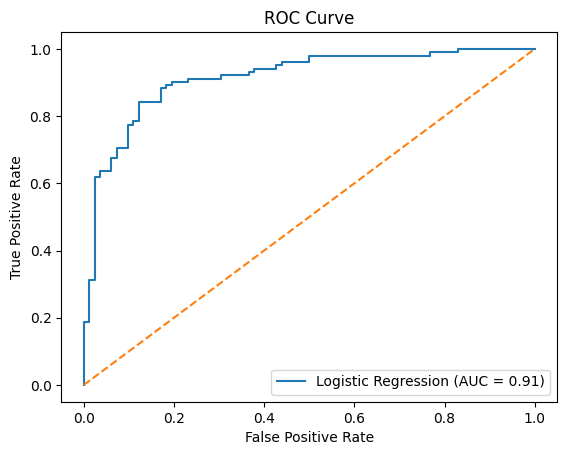

In [34]:
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [35]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [36]:

print("Accuracy:", accuracy_score(y_test, y_pred_knn))


print("Precision:", precision_score(y_test, y_pred_knn))


print("Recall:", recall_score(y_test, y_pred_knn))


print("F1 Score:", f1_score(y_test, y_pred_knn))


print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

Accuracy: 0.6521739130434783
Precision: 0.69
Recall: 0.6764705882352942
F1 Score: 0.6831683168316832

Confusion Matrix:
 [[51 31]
 [33 69]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.62      0.61        82
           1       0.69      0.68      0.68       102

    accuracy                           0.65       184
   macro avg       0.65      0.65      0.65       184
weighted avg       0.65      0.65      0.65       184



In [37]:
y_pred_knn = knn.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_knn)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.6927905308464849


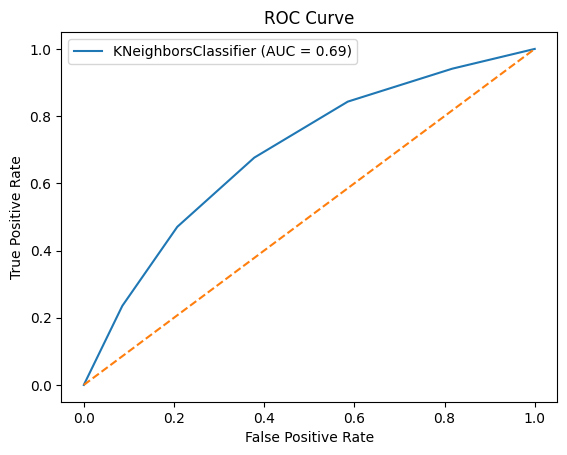

In [38]:
plt.plot(fpr, tpr, label=f"KNeighborsClassifier (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [39]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [40]:

print("Accuracy:", accuracy_score(y_test, y_pred_dt))


print("Precision:", precision_score(y_test, y_pred_dt))


print("Recall:", recall_score(y_test, y_pred_dt))


print("F1 Score:", f1_score(y_test, y_pred_dt))


print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.7717391304347826
Precision: 0.8409090909090909
Recall: 0.7254901960784313
F1 Score: 0.7789473684210526

Confusion Matrix:
 [[68 14]
 [28 74]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.83      0.76        82
           1       0.84      0.73      0.78       102

    accuracy                           0.77       184
   macro avg       0.77      0.78      0.77       184
weighted avg       0.78      0.77      0.77       184



In [41]:
y_pred_dt = dt.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_dt)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.7773792443806791


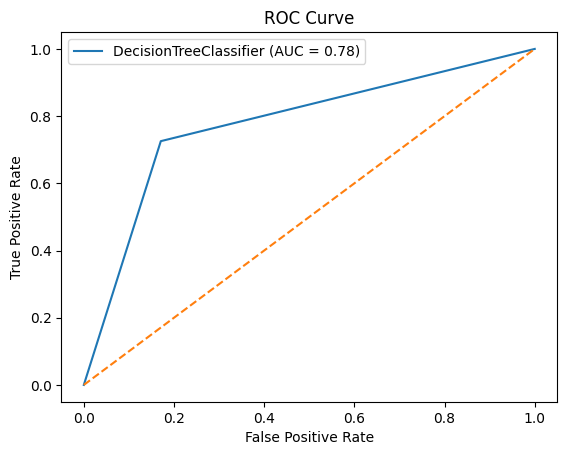

In [42]:
plt.plot(fpr, tpr, label=f"DecisionTreeClassifier (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [45]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


print("Precision:", precision_score(y_test, y_pred_rf))


print("Recall:", recall_score(y_test, y_pred_rf))


print("F1 Score:", f1_score(y_test, y_pred_rf))


print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.8641304347826086
Precision: 0.9052631578947369
Recall: 0.8431372549019608
F1 Score: 0.8730964467005076

Confusion Matrix:
 [[73  9]
 [16 86]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.85        82
           1       0.91      0.84      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184



In [46]:
y_pred_rf = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_rf)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.9194763271162123


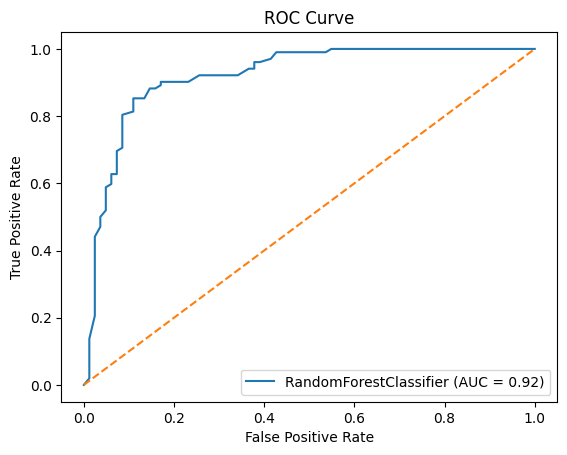

In [47]:
plt.plot(fpr, tpr, label=f"RandomForestClassifier (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [51]:
from sklearn.svm import SVC

svm = SVC(probability=True)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [52]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))


print("Precision:", precision_score(y_test,y_pred_svm ))


print("Recall:", recall_score(y_test,y_pred_svm ))


print("F1 Score:", f1_score(y_test,y_pred_svm ))


print("\nConfusion Matrix:\n", confusion_matrix(y_test,y_pred_svm ))

print("\nClassification Report:\n", classification_report(y_test,y_pred_svm ))

Accuracy: 0.6304347826086957
Precision: 0.6888888888888889
Recall: 0.6078431372549019
F1 Score: 0.6458333333333334

Confusion Matrix:
 [[54 28]
 [40 62]]

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.66      0.61        82
           1       0.69      0.61      0.65       102

    accuracy                           0.63       184
   macro avg       0.63      0.63      0.63       184
weighted avg       0.64      0.63      0.63       184



In [53]:
y_pred_svm =svm.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_svm)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.6939263510282161


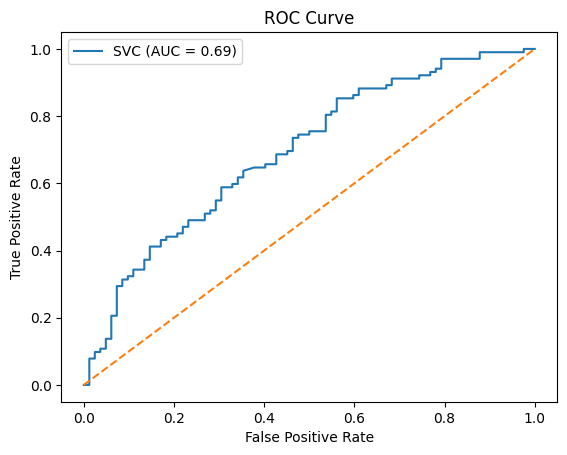

In [54]:
plt.plot(fpr, tpr, label=f"SVC (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [55]:
!pip install xgboost

In [56]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [57]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))


print("Precision:", precision_score(y_test,y_pred_xgb ))


print("Recall:", recall_score(y_test,y_pred_xgb ))


print("F1 Score:", f1_score(y_test,y_pred_xgb ))


print("\nConfusion Matrix:\n", confusion_matrix(y_test,y_pred_xgb ))

print("\nClassification Report:\n", classification_report(y_test,y_pred_xgb ))

Accuracy: 0.8260869565217391
Precision: 0.8723404255319149
Recall: 0.803921568627451
F1 Score: 0.8367346938775511

Confusion Matrix:
 [[70 12]
 [20 82]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.85      0.81        82
           1       0.87      0.80      0.84       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



In [58]:
y_pred_xgb =xgb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_xgb)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.912960306073649


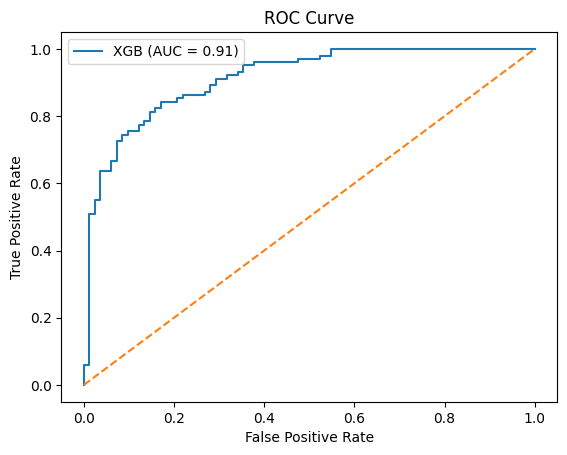

In [59]:
plt.plot(fpr, tpr, label=f"XGB (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [63]:
results = []

models = {
    "Logistic Regression": lr,
    "K-Nearest Neighbors": knn,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Support Vector Machine": svm,
    "XGBoost": xgb
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

df_results = pd.DataFrame(results)

df_results = df_results.sort_values(by="F1 Score", ascending=False)

df_results

,Model,Accuracy,Recall,F1 Score
3,Random Forest,0.864130,0.843137,0.873096
0,Logistic Regression,0.836957,0.843137,0.851485
5,XGBoost,0.826087,0.803922,0.836735
2,Decision Tree,0.771739,0.725490,0.778947
1,K-Nearest Neighbors,0.652174,0.676471,0.683168
4,Support Vector Machine,0.630435,0.607843,0.645833
